# 04 — Experiment 3: ambulatory motion

`E3_walk` — 180 s recording: 0-60 s seated, 60-120 s walking, 120-180 s recovery.

Anchor seated reference: **E1B** (sitting 5 min). Walking HRV is flagged
**unreliable** due to motion artifact; we still report it for completeness.

**Deliverables**:
- Figure 3.1 — full tachogram with segment shading.
- Figure 3.2 — raw ECG 15 s per segment (shows motion artifact in walking).
- Figure 3.3 — recovery HR with exponential tau fit.
- Figure 3.4 — ECG PSD with accelerometer-derived cadence reference.
- Figure 3.5 — motion-g(t) with smoothed envelope aligned to the RR tachogram.
- Table 3.1 — per-segment stats + anchor comparison.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config as cfg
from src import pipeline as P
from src import plotting as PL

PL.apply_style()
warnings.filterwarnings('ignore', category=RuntimeWarning)

FIG_DIR = REPO_ROOT / 'outputs' / 'figures'
TBL_DIR = REPO_ROOT / 'outputs' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete. Sessions available:', len(cfg.SESSION_MAP))

Setup complete. Sessions available: 14


## 1. Load pipeline + anchor + gsen

In [2]:
r  = P.analyze_transient_event("E3_walk")
r_anc = P.analyze_steady_state("E1B")
t_g, motion_g = P.load_gsen("E3_walk")
print(f"E3_walk:  {r.peaks_nk.size} peaks over {r.ecg_raw.size/cfg.FS:.1f}s")
print(f"E1B anchor: HR={r_anc.td_hrv['mean_hr_bpm']:.1f} bpm, HF={r_anc.fd_hrv['hf_ms2']:.0f} ms²")
for seg, d in r.extras["transient_hrv"].items():
    print(f"  {seg:10s}: HR={d['mean_hr_bpm']:.1f} bpm  RMSSD={d['rmssd_ms']:.1f}  "
          f"slope={d['hr_slope_bpm_per_s']:+.3f}  n_beats={d['n_beats']}")

E3_walk:  213 peaks over 180.0s
E1B anchor: HR=56.1 bpm, HF=1123 ms²
  seated    : HR=60.8 bpm  RMSSD=54.4  slope=-0.055  n_beats=60
  walking   : HR=83.0 bpm  RMSSD=41.1  slope=-0.120  n_beats=82
  recovery  : HR=70.3 bpm  RMSSD=46.9  slope=-0.134  n_beats=70


## 2. Figure 3.1 — full tachogram with segment shading

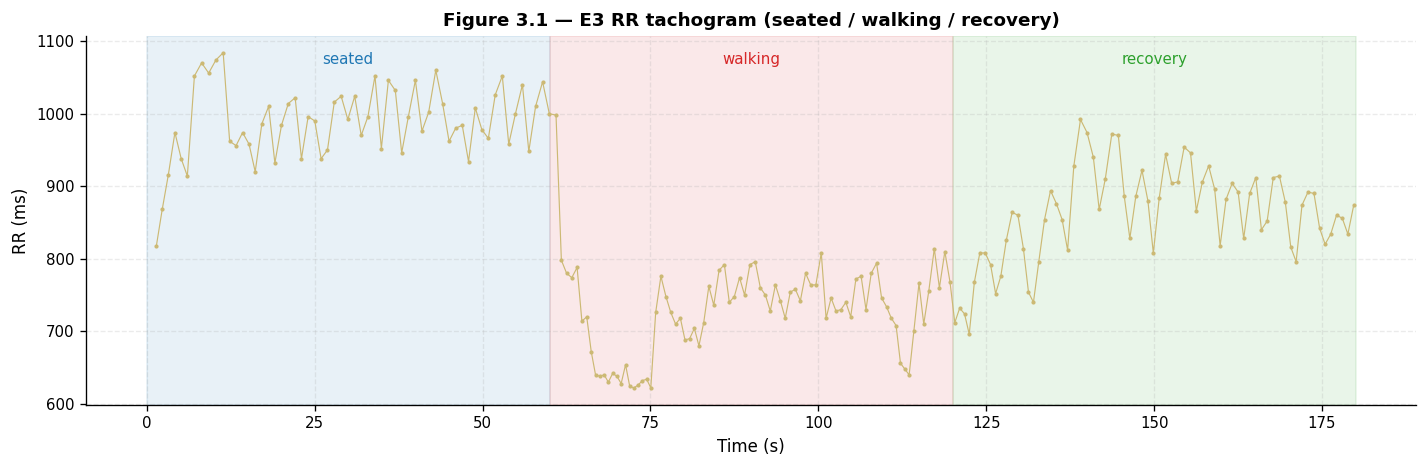

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
PL.plot_rr_tachogram(r.rr_ms_nk, r.rr_times_nk, ax=ax,
    color=PL.STYLE_COLORS["E3_walk"],
    title="Figure 3.1 — E3 RR tachogram (seated / walking / recovery)")
for name, (t0, t1) in cfg.E3_SEG.items():
    color = {"seated":"tab:blue","walking":"tab:red","recovery":"tab:green"}[name]
    ax.axvspan(t0, t1, color=color, alpha=0.10)
    ax.text((t0+t1)/2, ax.get_ylim()[1]*0.98, name,
            ha="center", va="top", fontsize=9, color=color)
fig.tight_layout()
PL.save_figure(fig, "nb04_fig01_e3_tachogram.pdf")
plt.show()

## 3. Figure 3.2 — raw ECG 15 s per segment (motion artifact visible)

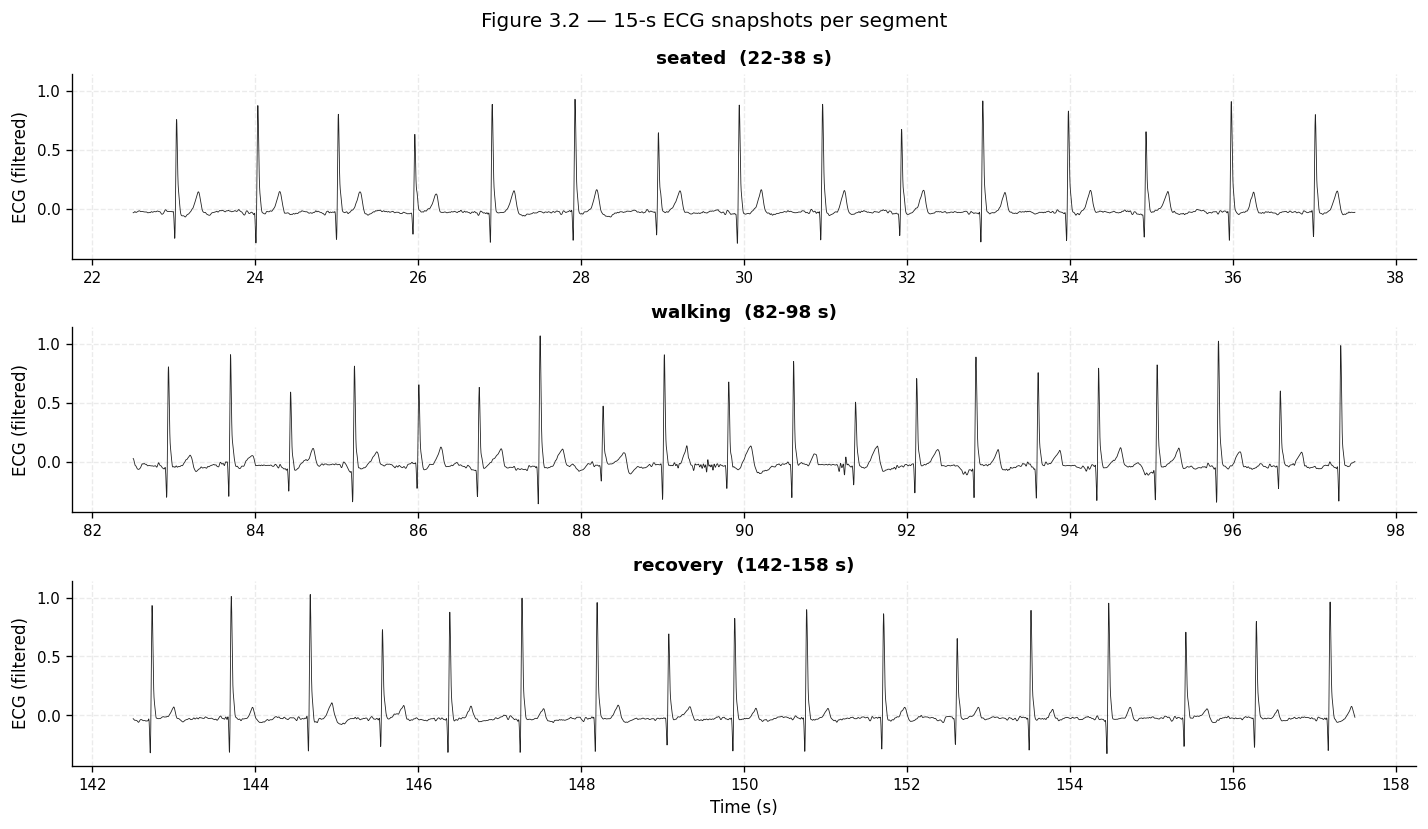

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharey=True)
for ax, (name, (t0, t1)) in zip(axes, cfg.E3_SEG.items()):
    mid = (t0 + t1) / 2
    i0 = int((mid - 7.5) * cfg.FS)
    i1 = int((mid + 7.5) * cfg.FS)
    i0 = max(0, i0); i1 = min(r.ecg_filt.size, i1)
    t_seg = r.t[i0:i1]
    ax.plot(t_seg, r.ecg_filt[i0:i1], linewidth=0.5, color="#222")
    ax.set_title(f"{name}  ({mid-7.5:.0f}-{mid+7.5:.0f} s)")
    ax.set_ylabel("ECG (filtered)")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Figure 3.2 — 15-s ECG snapshots per segment", fontsize=12)
fig.tight_layout()
PL.save_figure(fig, "nb04_fig02_e3_ecg_snapshots.pdf")
plt.show()

## 4. Figure 3.3 — recovery HR with exponential tau fit

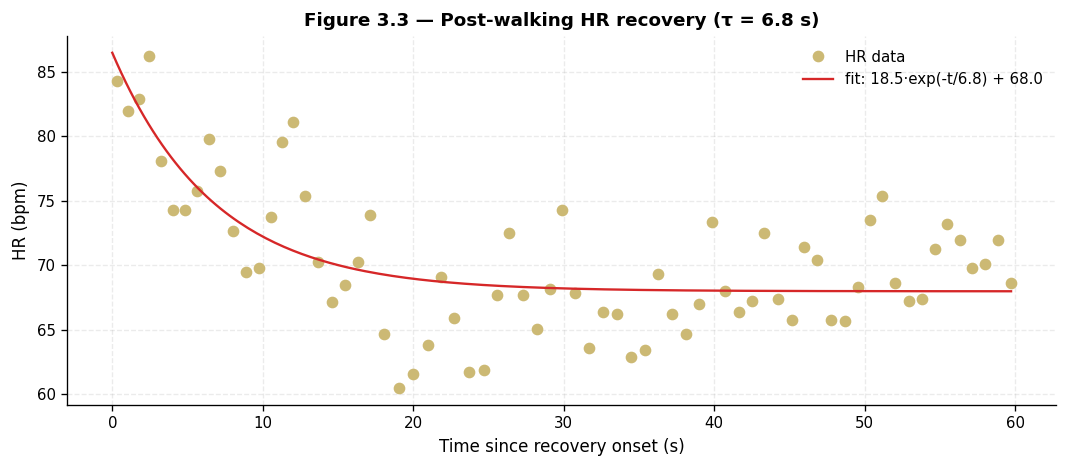

In [5]:
from scipy.optimize import curve_fit

def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

t_rec0, t_rec1 = cfg.E3_SEG["recovery"]
mask = (r.rr_times_nk >= t_rec0) & (r.rr_times_nk < t_rec1)
t_rec = r.rr_times_nk[mask] - t_rec0
hr_rec = 60000.0 / r.rr_ms_nk[mask]

try:
    popt, _ = curve_fit(exp_decay, t_rec, hr_rec,
                        p0=[hr_rec[0]-hr_rec[-1], 20.0, hr_rec[-1]],
                        maxfev=5000)
    A, tau, C = popt
    t_fit = np.linspace(0, t_rec.max(), 200)
    hr_fit = exp_decay(t_fit, *popt)
    fit_ok = True
except Exception as exc:
    A = tau = C = float("nan"); fit_ok = False
    print(f"Fit failed: {exc}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_rec, hr_rec, "o", color=PL.STYLE_COLORS["E3_walk"], label="HR data")
if fit_ok:
    ax.plot(t_fit, hr_fit, "-", color="tab:red", linewidth=1.4,
            label=f"fit: {A:.1f}·exp(-t/{tau:.1f}) + {C:.1f}")
ax.set_xlabel("Time since recovery onset (s)")
ax.set_ylabel("HR (bpm)")
ax.set_title(f"Figure 3.3 — Post-walking HR recovery (τ = {tau:.1f} s)")
ax.legend()
fig.tight_layout()
PL.save_figure(fig, "nb04_fig03_e3_recovery_tau.pdf")
plt.show()

## 5. Figure 3.4 — ECG PSD with accelerometer-derived cadence reference


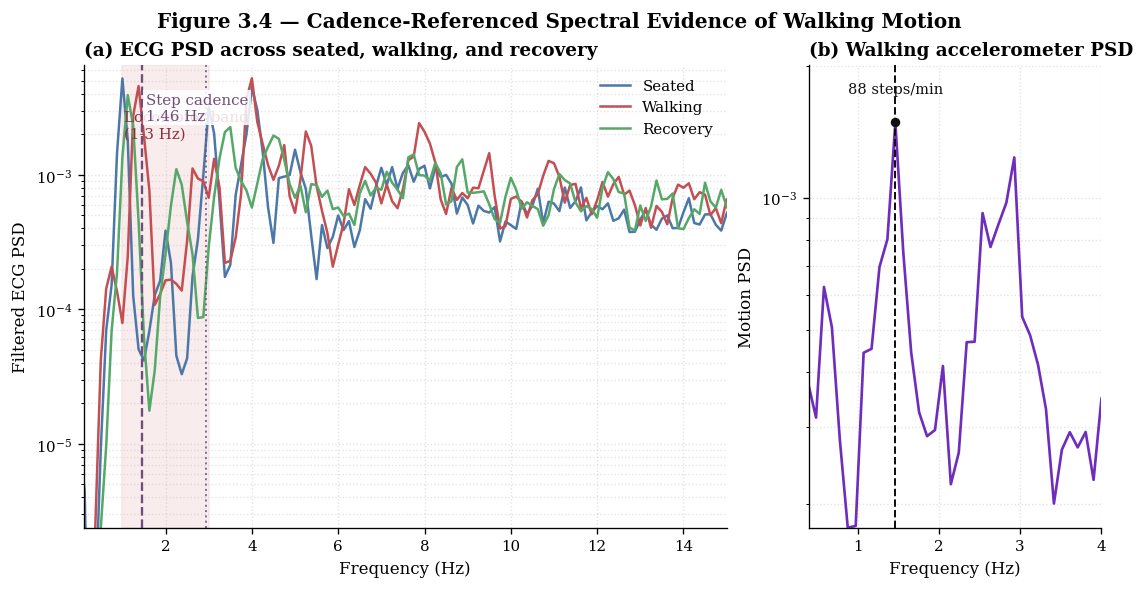

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
})
segments = ["seated", "walking", "recovery"]
colors = {"seated": "#4C78A8", "walking": "#C44E52", "recovery": "#55A868"}
seg_titles = {"seated": "Seated", "walking": "Walking", "recovery": "Recovery"}
ecg_psd_by_seg = {}
for seg_name in segments:
    t0, t1 = cfg.E3_SEG[seg_name]
    i0, i1 = int(t0 * cfg.FS), int(t1 * cfg.FS)
    ecg_seg = r.ecg_filt[i0:i1]
    f_ecg, p_ecg = P.ecg_psd(ecg_seg, fs=cfg.FS, nperseg_sec=8)
    ecg_psd_by_seg[seg_name] = (f_ecg, p_ecg)
t0w, t1w = cfg.E3_SEG["walking"]
m_w = (t_g >= t0w) & (t_g < t1w)
f_g, p_g = welch(
    motion_g[m_w] - np.mean(motion_g[m_w]),
    fs=cfg.FS_GSEN,
    nperseg=min(256, int(np.sum(m_w))),
)
cadence_mask = (f_g >= 0.8) & (f_g <= 3.5)
step_peak_hz = float(f_g[cadence_mask][np.argmax(p_g[cadence_mask])]) if cadence_mask.any() else float("nan")
step_peak_spm = 60.0 * step_peak_hz
fig = plt.figure(figsize=(9.2, 4.8), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[2.2, 1.0])
ax_ecg = fig.add_subplot(gs[0, 0])
ax_g = fig.add_subplot(gs[0, 1])
for seg_name in segments:
    f_ecg, p_ecg = ecg_psd_by_seg[seg_name]
    ax_ecg.semilogy(f_ecg, p_ecg, color=colors[seg_name], lw=1.5, label=seg_titles[seg_name])
ecg_band = []
for f_ecg, p_ecg in ecg_psd_by_seg.values():
    mask = (f_ecg >= 0.5) & (f_ecg <= 15.0) & np.isfinite(p_ecg) & (p_ecg > 0)
    if np.any(mask):
        ecg_band.append(p_ecg[mask])
if ecg_band:
    ecg_vals = np.concatenate(ecg_band)
    ecg_ymax = float(np.max(ecg_vals) * 1.25)
    ecg_ymin = float(max(np.min(ecg_vals), ecg_ymax / 1e4))
    ax_ecg.set_ylim(ecg_ymin, ecg_ymax)
else:
    ecg_ymax = ax_ecg.get_ylim()[1]
ax_ecg.axvspan(1.0, 3.0, color="#F3D6D8", alpha=0.45, zorder=-2)
ax_ecg.text(
    1.04, ecg_ymax / 2.8, "Locomotor band\n(1-3 Hz)",
    color="#8C2D3C", fontsize=9, ha="left", va="center",
)
if np.isfinite(step_peak_hz):
    ax_ecg.axvline(step_peak_hz, color="#6F4E7C", linestyle="--", lw=1.4)
    if 2 * step_peak_hz <= 15:
        ax_ecg.axvline(2 * step_peak_hz, color="#6F4E7C", linestyle=":", lw=1.2, alpha=0.8)
    ax_ecg.text(
        step_peak_hz + 0.08, ecg_ymax / 1.6,
        f"Step cadence\n{step_peak_hz:.2f} Hz",
        color="#6F4E7C", fontsize=9, ha="left", va="top",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5),
    )
ax_ecg.set_xlim(0.1, 15.0)
ax_ecg.set_xlabel("Frequency (Hz)")
ax_ecg.set_ylabel("Filtered ECG PSD")
ax_ecg.set_title("(a) ECG PSD across seated, walking, and recovery", loc="left", fontweight="bold")
ax_ecg.grid(True, which="both", linestyle=":", alpha=0.35)
ax_ecg.legend(loc="upper right", framealpha=0.95)
ax_g.semilogy(f_g, p_g, color="#6F2DBD", lw=1.6)
g_mask = (f_g >= 0.4) & (f_g <= 4.0) & np.isfinite(p_g) & (p_g > 0)
if np.any(g_mask):
    g_vals = p_g[g_mask]
    g_ymax = float(np.max(g_vals) * 1.35)
    g_ymin = float(max(np.min(g_vals), g_ymax / 1e3))
    ax_g.set_ylim(g_ymin, g_ymax)
else:
    g_ymax = ax_g.get_ylim()[1]
if np.isfinite(step_peak_hz):
    peak_power = float(np.interp(step_peak_hz, f_g, p_g))
    ax_g.axvline(step_peak_hz, color="#111111", linestyle="--", lw=1.2)
    ax_g.scatter([step_peak_hz], [peak_power], color="#111111", s=22, zorder=5)
    ax_g.text(
        step_peak_hz, min(peak_power * 1.15, g_ymax / 1.08),
        f"{step_peak_spm:.0f} steps/min",
        fontsize=8.8, ha="center", va="bottom", color="#111111",
    )
ax_g.set_xlim(0.4, 4.0)
ax_g.set_xlabel("Frequency (Hz)")
ax_g.set_ylabel("Motion PSD")
ax_g.set_title("(b) Walking accelerometer PSD", loc="left", fontweight="bold")
ax_g.grid(True, which="both", linestyle=":", alpha=0.35)
fig.suptitle(
    "Figure 3.4 — Cadence-Referenced Spectral Evidence of Walking Motion",
    fontsize=12, fontweight="bold",
)
PL.save_figure(fig, 'nb04_fig04_e3_ecg_psd.pdf')
plt.show()


## 6. Figure 3.5 — motion-g(t) with smoothed envelope aligned to RR


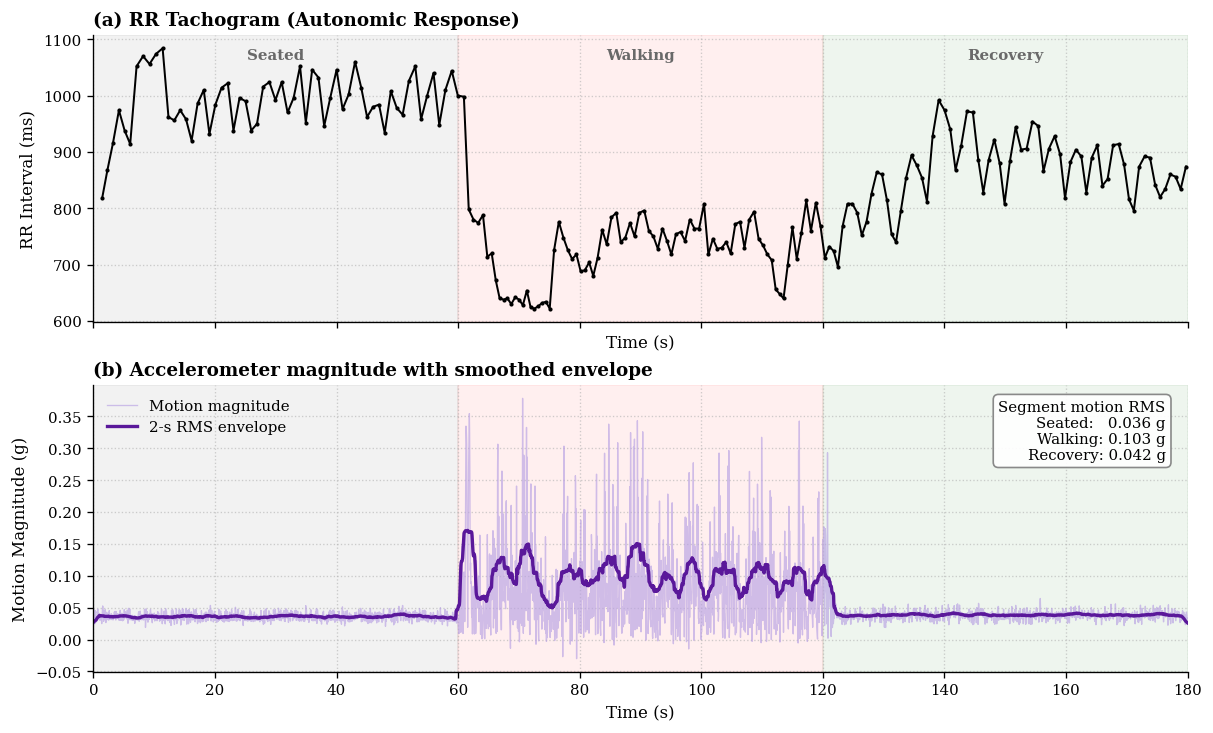

In [7]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
})
def moving_rms(x, window_samples):
    if window_samples <= 1:
        return np.asarray(x, dtype=float)
    kernel = np.ones(window_samples, dtype=float) / window_samples
    return np.sqrt(np.convolve(np.square(x), kernel, mode='same'))
env_win_s = 2.0
env_win_n = max(3, int(round(env_win_s * cfg.FS_GSEN)))
motion_env = moving_rms(motion_g, env_win_n)
motion_rms = {}
for seg_name, (t0, t1) in cfg.E3_SEG.items():
    m = (t_g >= t0) & (t_g < t1)
    motion_rms[seg_name] = float(np.sqrt(np.mean(np.square(motion_g[m])))) if np.any(m) else float("nan")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)
SEG_COLORS = {"seated": "#A9A9A9", "walking": "#FF9999", "recovery": "#8FBC8F"}
ax_rr = axes[0]
PL.plot_rr_tachogram(r.rr_ms_nk, r.rr_times_nk, ax=ax_rr, color='black', lw=1.2)
ax_rr.set_title("(a) RR Tachogram (Autonomic Response)", loc='left', fontweight='bold')
ax_rr.set_ylabel("RR Interval (ms)")
ax_rr.grid(True, linestyle=':', alpha=0.6)
ax_g = axes[1]
ax_g.plot(t_g, motion_g, color="#B8A1E3", linewidth=0.8, alpha=0.65, label="Motion magnitude")
ax_g.plot(t_g, motion_env, color="#5A189A", linewidth=2.0, label=f"{env_win_s:.0f}-s RMS envelope")
ax_g.set_title("(b) Accelerometer magnitude with smoothed envelope", loc='left', fontweight='bold')
ax_g.set_ylabel("Motion Magnitude (g)")
ax_g.set_xlabel("Time (s)")
ax_g.grid(True, linestyle=':', alpha=0.6)
ax_g.set_xlim(0, 180)
for name, (t0, t1) in cfg.E3_SEG.items():
    c = SEG_COLORS.get(name, "gray")
    ax_rr.axvspan(t0, t1, color=c, alpha=0.15, zorder=-1)
    ax_g.axvspan(t0, t1, color=c, alpha=0.15, zorder=-1)
    ax_rr.text((t0 + t1) / 2, ax_rr.get_ylim()[1] * 0.98, name.capitalize(),
               ha="center", va="top", fontsize=9, fontweight='bold', color='dimgray')
stats_text = (
    "Segment motion RMS\n"
    f"Seated:   {motion_rms['seated']:.3f} g\n"
    f"Walking: {motion_rms['walking']:.3f} g\n"
    f"Recovery: {motion_rms['recovery']:.3f} g"
)
ax_g.text(
    0.98, 0.95, stats_text,
    transform=ax_g.transAxes,
    fontsize=9,
    color='black',
    ha='right',
    va='top',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.92, edgecolor='gray'),
)
ax_g.legend(loc="upper left", framealpha=0.95)
PL.save_figure(fig, 'nb04_fig05_e3_motion_crosscheck.pdf')
plt.show()


## 7. Table 3.1 — per-segment stats + anchor comparison

In [8]:
if 'motion_rms' not in globals():
    motion_rms = {}
    for seg_name, (t0, t1) in cfg.E3_SEG.items():
        m = (t_g >= t0) & (t_g < t1)
        motion_rms[seg_name] = float(np.sqrt(np.mean(np.square(motion_g[m])))) if np.any(m) else float("nan")
rows = []
for seg_name, d in r.extras["transient_hrv"].items():
    rows.append({
        "Segment": seg_name,
        "Range (s)": f"{cfg.E3_SEG[seg_name][0]:.0f}-{cfg.E3_SEG[seg_name][1]:.0f}",
        "n_beats":   d["n_beats"],
        "Mean HR (bpm)": d["mean_hr_bpm"],
        "Min HR (bpm)":  d["min_hr_bpm"],
        "Max HR (bpm)":  d["max_hr_bpm"],
        "RMSSD (ms)":    d["rmssd_ms"],
        "HR slope (bpm/s)": d["hr_slope_bpm_per_s"],
        "Motion RMS (g)": motion_rms.get(seg_name, float("nan")),
        "Note":      "**UNRELIABLE (motion)**" if seg_name == "walking" else "",
    })
rows.append({
    "Segment": "E1B anchor",
    "Range (s)": "300 (5 min)",
    "n_beats": int(r_anc.peaks_nk.size),
    "Mean HR (bpm)": r_anc.td_hrv["mean_hr_bpm"],
    "Min HR (bpm)":  r_anc.td_hrv["min_hr_bpm"],
    "Max HR (bpm)":  r_anc.td_hrv["max_hr_bpm"],
    "RMSSD (ms)":    r_anc.td_hrv["rmssd_ms"],
    "HR slope (bpm/s)": float("nan"),
    "Motion RMS (g)": float("nan"),
    "Note": "seated reference",
})
df_t31 = pd.DataFrame(rows)
df_t31["Recovery τ (s)"] = ""
df_t31.loc[df_t31["Segment"]=="recovery", "Recovery τ (s)"] = f"{tau:.1f}" if fit_ok else ""
df_t31.to_csv(TBL_DIR / "table_3_1_walking.csv", index=False)
df_t31.style.set_caption("Table 3.1 — E3 segment HRV vs E1B sitting anchor")


,Segment,Range (s),n_beats,Mean HR (bpm),Min HR (bpm),Max HR (bpm),RMSSD (ms),HR slope (bpm/s),Motion RMS (g),Note,Recovery τ (s)
0,seated,0-60,60,60.844730,55.350554,73.349633,54.396535,-0.054605,0.036089,,
1,walking,60-120,82,83.047285,60.120240,96.463023,41.060630,-0.119521,0.103279,**UNRELIABLE (motion)**,
2,recovery,120-180,70,70.284360,60.483871,86.206897,46.872630,-0.134047,0.041697,,6.8
3,E1B anchor,300 (5 min),279,56.097250,49.180328,71.090047,61.126947,nan,nan,seated reference,
